In [1]:
import numpy as np
np.random.seed(123)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

import shap

C:\Users\ADMIN\tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data  = pd.read_csv('diabetes.csv', index_col=0)
data.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,,,,,,,,
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1


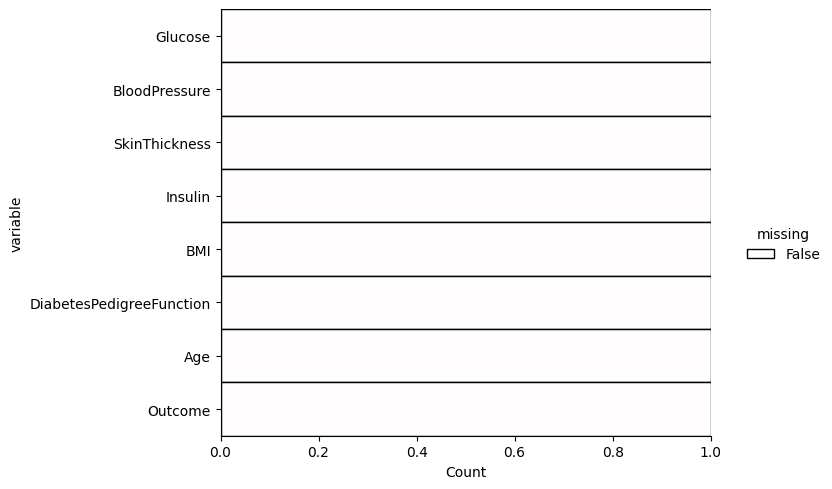

In [9]:
sns.displot(
    data=data.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.5,
    palette='seismic'
)
plt.show()

In [11]:
x = data.drop(columns=['Outcome'])
y= data['Outcome']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=123)

In [12]:
data_train=lgb.Dataset(x_train,y_train)

In [18]:
data_test=lgb.Dataset(x_test,y_test)
params={'metric':'auc',
       'learning_rate':0.05}

In [19]:
l=lgb.train(params,data_train,num_boost_round=100)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000220 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 655
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 7
[LightGBM] [Info] Start training from score 0.342020
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [21]:
y_pred = l.predict(x_test)

In [23]:
y_pred = [1 if y > 0.5 else 0 for y in y_pred]
print(f'Accuracy for the baseline model is: {accuracy_score(y_test, y_pred)}')

Accuracy for the baseline model is: 0.7597402597402597


In [24]:
explainer=shap.TreeExplainer(l)

In [25]:
shap_values=explainer.shap_values(x_test)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19048\320409636.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,x_test)


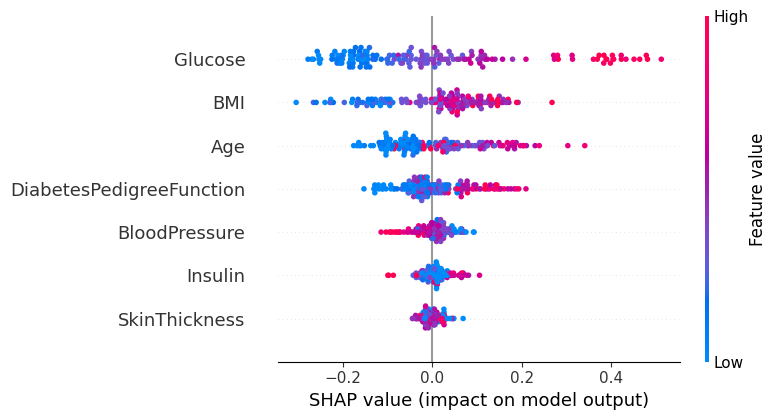

In [27]:
shap.summary_plot(shap_values,x_test)

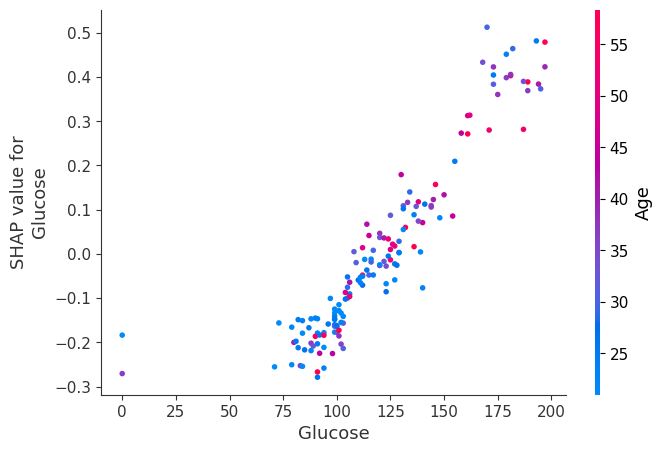

In [30]:
shap.dependence_plot("Glucose",shap_values,x_test)

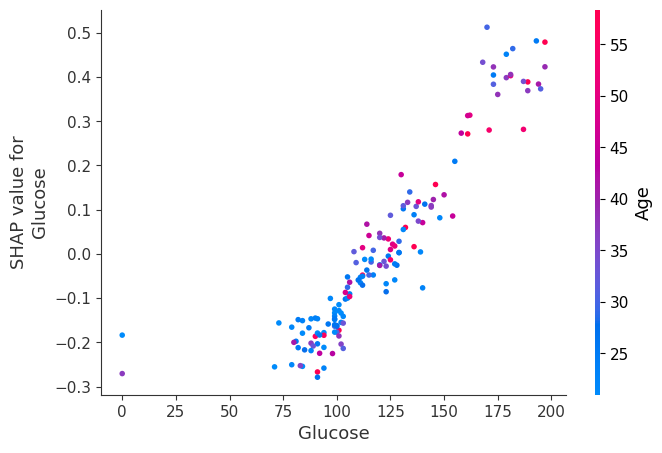

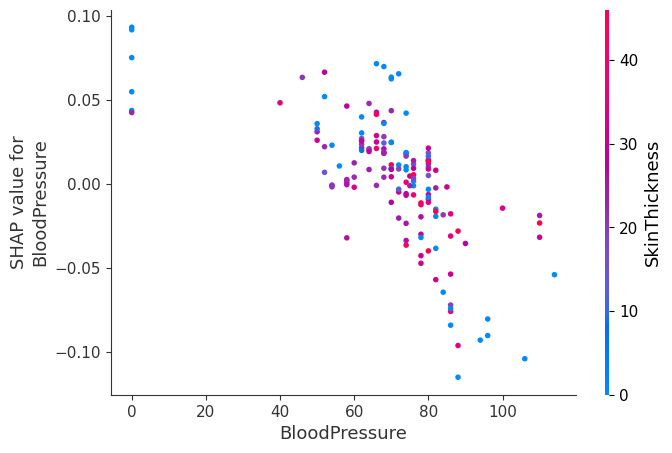

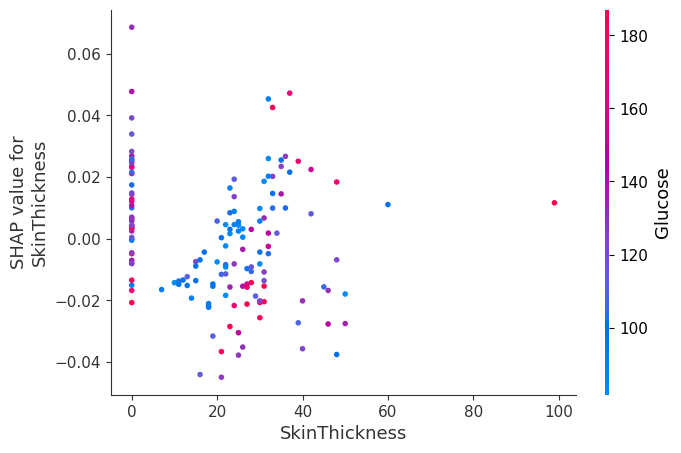

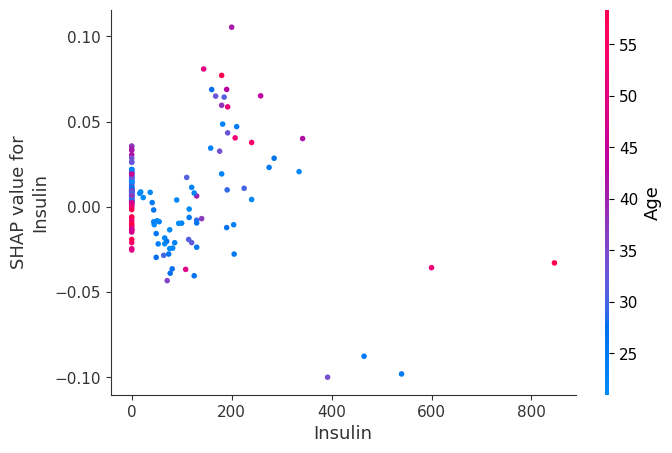

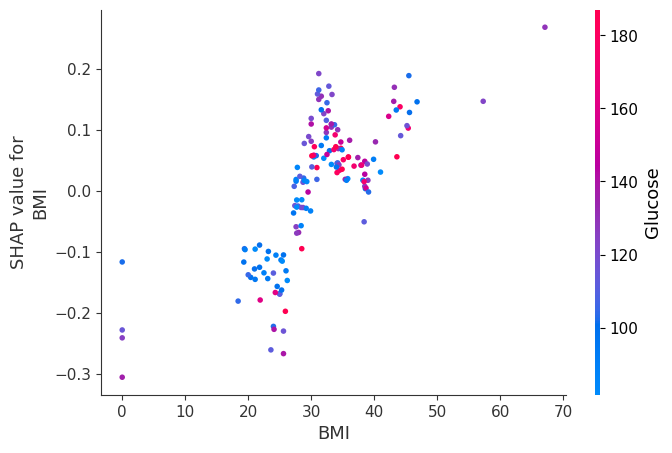

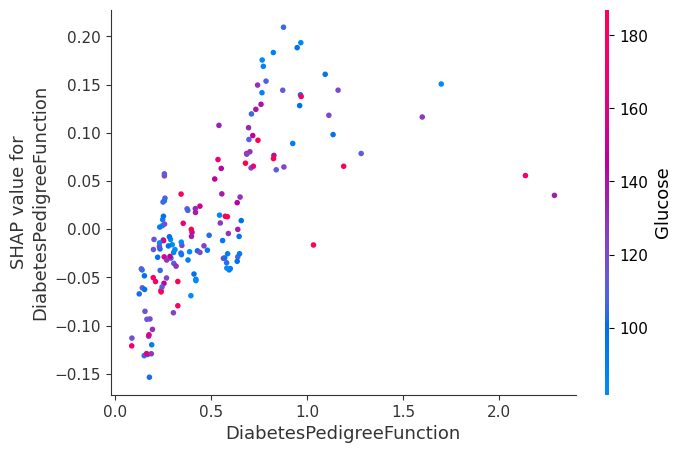

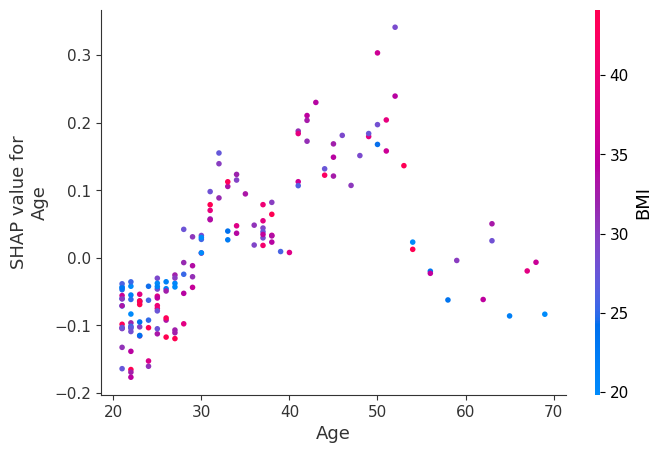

In [31]:
for i in x_test.columns:
    shap.dependence_plot(i,shap_values,x_test)
    

In [ ]:
shap.decis